# chemsar quickstart: end-to-end QSAR pipeline

This notebook walks through the full workflow, then goes a bit further:
preparing molecules, computing descriptors, building a dataset,
preprocessing it, training/evaluating a model, comparing algorithms and
hyperparameters, explaining predictions (global and per-molecule), drawing
2D structures, and training a small Keras classifier with confusion-matrix
visualization.

1. Prepare molecules
2. Generate descriptors + a synthetic activity
3. Preprocess the dataset
4. Train and evaluate a model
5. Predicted vs. observed
6. **Algorithm comparison** across several regressor types
7. **Hyperparameter search** over a random forest's `c` argument
8. **Feature importance**: variable importance + partial dependence
9. **LIME**: explaining one molecule's prediction
10. **2D structure depictions**, including substructure highlighting
11. **Classification + a Keras deep-learning model + confusion matrices**

**About the data:** the molecules below are real, simple, well-known
compounds (aspirin, caffeine, ibuprofen, etc.), but the "activity" (`IC50`)
values are **synthetically generated** for this notebook -- a made-up
function of molecular weight and polar surface area, plus noise -- purely so
the pipeline has something meaningful to learn from. They are *not* real
experimental measurements.

All outputs this notebook writes (prepared structures, descriptor tables,
diagnostic CSVs) go into `examples/output/`, which is git-ignored.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

from chemsar import mol_enumerate, desc, dataframe, data_prep, Model

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)
os.chdir(OUTPUT_DIR)  # chemsar's preprocessing/modeling functions write several
                      # diagnostic CSVs to the current working directory
np.random.seed(0)

Failed to patch pandas - PandasTools will have limited functionality


## 1. Example molecules

A small, diverse set of well-known small molecules, written out as a
SMILES file (the format `mol_enumerate` expects for `input_format="smi"`).

In [2]:
molecules = {
    "aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "caffeine": "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "ethanol": "CCO",
    "benzene": "c1ccccc1",
    "toluene": "Cc1ccccc1",
    "phenol": "Oc1ccccc1",
    "acetone": "CC(=O)C",
    "acetic_acid": "CC(=O)O",
    "naphthalene": "c1ccc2ccccc2c1",
    "pyridine": "c1ccncc1",
    "furan": "c1ccoc1",
    "thiophene": "c1ccsc1",
    "imidazole": "c1cnc[nH]1",
    "indole": "c1ccc2[nH]ccc2c1",
    "quinoline": "c1ccc2ncccc2c1",
    "cyclohexane": "C1CCCCC1",
    "methanol": "CO",
    "propanol": "CCCO",
    "butanol": "CCCCO",
    "chlorobenzene": "Clc1ccccc1",
    "bromobenzene": "Brc1ccccc1",
    "nitrobenzene": "O=[N+]([O-])c1ccccc1",
    "aniline": "Nc1ccccc1",
    "benzaldehyde": "O=Cc1ccccc1",
    "benzoic_acid": "O=C(O)c1ccccc1",
    "styrene": "C=Cc1ccccc1",
    "anisole": "COc1ccccc1",
    "salicylic_acid": "O=C(O)c1ccccc1O",
}

smi_df = pd.DataFrame(
    {"smiles": molecules.values(), "name": molecules.keys()}
)
smi_df.to_csv("molecules.smi", index=False)
smi_df

,smiles,name
0,CC(=O)Oc1ccccc1C(=O)O,aspirin
1,Cn1cnc2c1c(=O)n(C)c(=O)n2C,caffeine
2,CC(C)Cc1ccc(cc1)C(C)C(=O)O,ibuprofen
3,CC(=O)Nc1ccc(O)cc1,paracetamol
4,CCO,ethanol
5,c1ccccc1,benzene
6,Cc1ccccc1,toluene
7,Oc1ccccc1,phenol
8,CC(=O)C,acetone
9,CC(=O)O,acetic_acid


## 2. Prepare molecules

`mol_enumerate` strips salts, embeds a 3D conformer, and computes Gasteiger
charges for each molecule, writing both a 3D and a 2D SDF.

In [3]:
prepared = mol_enumerate(
    "molecules.smi",
    "prepared_3d.sdf",
    "prepared_2d.sdf",
    input_format="smi",
)
print(f"prepared {len(prepared)} of {len(molecules)} molecules")

len(input_molecules) 30
0 aspirin to 3d
skipping molecule 9: failed to prepare molecule 'acetic_acid': molecule has no atoms


prepared 29 of 30 molecules


You'll see `acetic_acid` get skipped with a warning rather than silently
dropped or replaced: RDKit's default `SaltRemover` treats acetic acid itself
as a salt/counter-ion, so stripping it leaves zero atoms. `mol_enumerate`
raises a clear error for molecules like this and skips them, rather than
(as an earlier version of this pipeline did) silently substituting a fake
placeholder molecule and continuing.

## 3. Generate descriptors and a synthetic activity

`desc()` computes RDKit descriptors for every prepared molecule; we use the
"interpretable" subset (counts, fragment counts, molecular weight, TPSA --
easy to reason about for a demo). Then we simulate an activity value and
merge it in with `dataframe()`, matching by molecule name.

In [4]:
desc_result = desc("prepared_3d.sdf", source="sdf", selected_des="interpretable")
names, descriptor_names, values = desc_result
print(f"{len(descriptor_names)} descriptors computed for {len(names)} molecules")

desc_df = pd.DataFrame(values, index=names, columns=descriptor_names)

# Synthetic activity: a made-up function of MolWt/TPSA plus noise, purely to
# give the model a learnable (but fake) signal.
synthetic_ic50 = (
    -0.05 * desc_df["MolWt"]
    - 0.1 * desc_df["TPSA"]
    + np.random.normal(scale=2.0, size=len(desc_df))
)
activities = pd.DataFrame({"name": names, "IC50": synthetic_ic50.values})
activities.to_csv("activities.csv", index=False)

merged = dataframe(desc_result, "activities.csv", "merged.csv", target="IC50")
merged.head()

110 descriptors computed for 29 molecules


,name,IC50,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,TPSA,NumAliphaticCarbocycles,NumAliphaticHeterocycles,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,aspirin,-11.839845,180.159,172.095,180.042259,68,0,63.60,0,0,...,0,0,0,0,0,0,0,0,0,0
1,caffeine,-15.091386,194.194,184.114,194.080376,74,0,61.82,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ibuprofen,-12.086774,206.285,188.141,206.130680,82,0,37.30,0,0,...,0,0,0,0,0,0,0,0,0,0
3,paracetamol,-8.009464,151.165,142.093,151.063329,58,0,49.33,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ethanol,-0.591334,46.069,40.021,46.041865,20,0,20.23,0,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Preprocess the dataset

`data_prep` handles scaling, correlation filtering, feature selection, and
the train/test split in one call. It also writes an applicability-domain
(CI) report -- see `CI_train.csv` / `CI_test.csv` in `examples/output/`.

In [5]:
result = data_prep(
    "merged.csv",
    Scaled="on",
    Cor="on",
    FS="reg",
    ndes=6,
    mod="reg",
    ratio=0.25,
    rs=0,
)
X_train, y_train, X_test, y_test, v_names = result[:5]
print("selected features:", v_names)
print("train/test sizes:", X_train.shape, X_test.shape)

selected features: ['HeavyAtomMolWt', 'NumHAcceptors', 'NumRotatableBonds', 'fr_Ar_COO', 'fr_COO2', 'fr_NH0']
train/test sizes: (21, 6) (8, 6)


## 5. Train and evaluate a model

A random forest regressor, evaluated on the training fit, leave-one-out
cross-validation, and the held-out test set.

In [6]:
model_result, cv_metrics, fitted_model, analysis = Model(
    X_train, y_train, X_test, y_test, v_names, M="rf", c=3, rs=0, cv="loo"
)

print("Train R^2:      %.3f" % model_result["R2"])
print("Test R^2:       %.3f" % model_result["R2_test"])
print("CV Q^2 (LOO):   %.3f" % cv_metrics["q2"])
print("CV RMSE (LOO):  %.3f" % cv_metrics["RMSECV"])
model_result["Variable Importance"]

Train R^2:      0.690
Test R^2:       0.225
CV Q^2 (LOO):   0.487
CV RMSE (LOO):  2.429


,0
NumRotatableBonds,0.009613
fr_COO2,0.013906
fr_NH0,0.029676
fr_Ar_COO,0.266647
HeavyAtomMolWt,0.323720
NumHAcceptors,0.356437


## 6. Predicted vs. observed

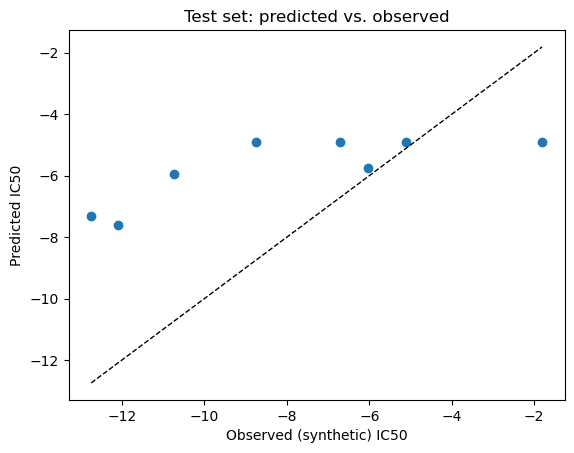

In [7]:
import matplotlib.pyplot as plt

y_pred_test = fitted_model.predict(X_test)

plt.scatter(y_test, y_pred_test)
lims = [min(*y_test, *y_pred_test), max(*y_test, *y_pred_test)]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("Observed (synthetic) IC50")
plt.ylabel("Predicted IC50")
plt.title("Test set: predicted vs. observed")
plt.show()

## 7. Algorithm comparison

`Model()` supports many regressor types through its `M` argument. A quick
way to pick a starting point is to fit several and compare their held-out
test R² and cross-validated Q².

In [8]:
candidate_models = ["mlr", "pls", "rf", "gb", "svm"]
comparison_rows = []
for m_name in candidate_models:
    res, cv, fitted, _ = Model(
        X_train, y_train, X_test, y_test, v_names, M=m_name, c=3, rs=0, cv="loo"
    )
    comparison_rows.append(
        {"model": m_name, "R2_test": res["R2_test"], "Q2_CV": cv["q2"]}
    )

comparison_df = pd.DataFrame(comparison_rows).set_index("model")
comparison_df

,R2_test,Q2_CV
model,,
mlr,0.406742,0.627041
pls,0.383419,0.658936
rf,0.225013,0.486858
gb,-0.212276,0.308910
svm,0.380765,0.474298


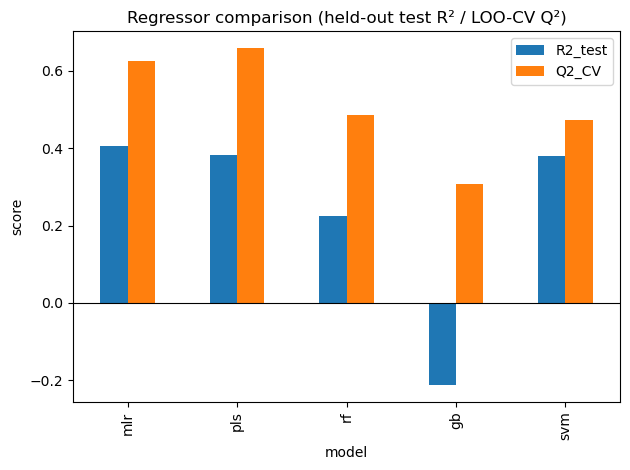

In [9]:
comparison_df.plot.bar()
plt.ylabel("score")
plt.title("Regressor comparison (held-out test R² / LOO-CV Q²)")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 8. Hyperparameter search

For `M="rf"`, the `c` argument controls `n_estimators`, `max_depth` (`c-1`),
and `max_features` (`c`) together. Sweeping it shows how the fit responds --
useful for picking a value, and a reminder that more trees/depth isn't
automatically better on a dataset this small.

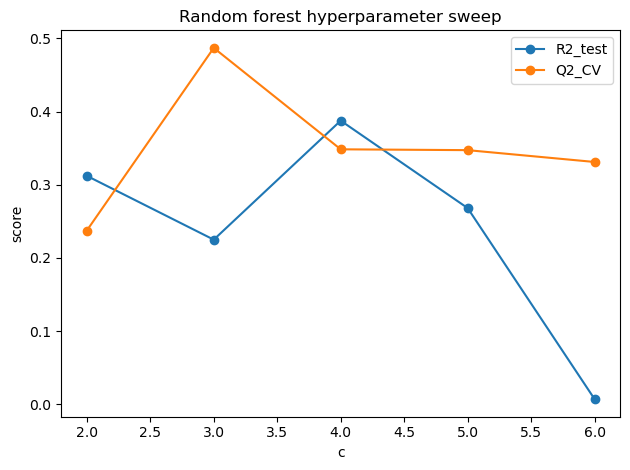

In [10]:
c_values = [2, 3, 4, 5, 6]
sweep_rows = []
for c in c_values:
    res, cv, fitted, _ = Model(
        X_train, y_train, X_test, y_test, v_names, M="rf", c=c, rs=0, cv="loo"
    )
    sweep_rows.append({"c": c, "R2_test": res["R2_test"], "Q2_CV": cv["q2"]})

sweep_df = pd.DataFrame(sweep_rows).set_index("c")
sweep_df.plot(marker="o")
plt.xlabel("c")
plt.ylabel("score")
plt.title("Random forest hyperparameter sweep")
plt.tight_layout()
plt.show()

## 9. Feature importance

`Model()`'s result already includes a sorted variable-importance table for
tree-based/linear models. `partial()` goes a step further with partial
dependence plots (fits a small gradient-boosted model internally on the
top-ranked features) -- it even accepts the same "Variable Importance"
table directly, since both use the same `{feature: score}` shape.

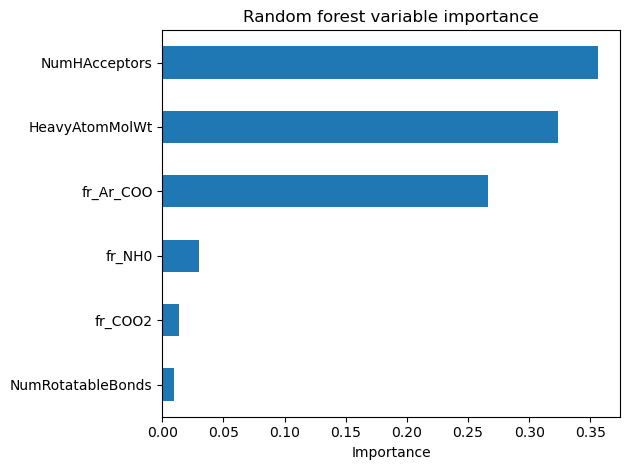

In [11]:
model_result["Variable Importance"].plot.barh(legend=False)
plt.xlabel("Importance")
plt.title("Random forest variable importance")
plt.tight_layout()
plt.show()

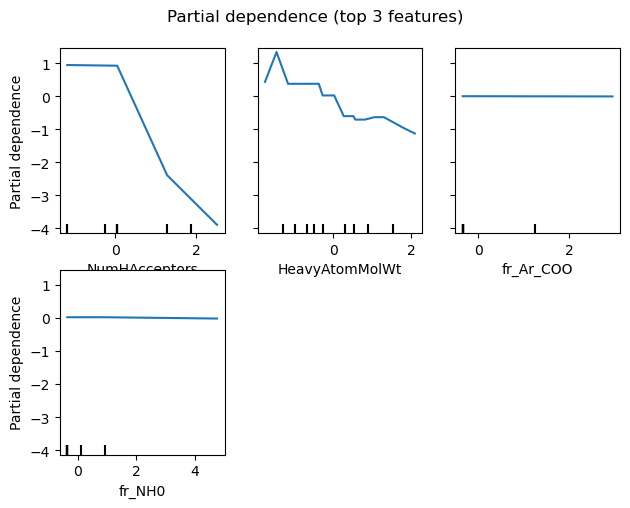

In [12]:
from chemsar import partial

partial(X_train, y_train, model_result["Variable Importance"], n_features=3, kind="reg", show=False)
plt.suptitle("Partial dependence (top 3 features)", y=1.05)
plt.show()

## 10. LIME: explaining a single prediction

Where variable importance and partial dependence describe the model
globally, LIME explains one prediction at a time -- which features pushed
*this molecule's* prediction up or down.

Molecule: 26
Observed: -5.12   Predicted: -4.18
  -0.46 < HeavyAtomMolWt <= -0.03     +0.891
  NumHAcceptors <= -0.27              +0.448
  fr_NH0 <= -0.35                     +0.252
  fr_Ar_COO <= -0.34                  +0.248
  -0.06 < NumRotatableBonds <= 0.50   +0.095
  fr_COO2 <= -0.40                    +0.059


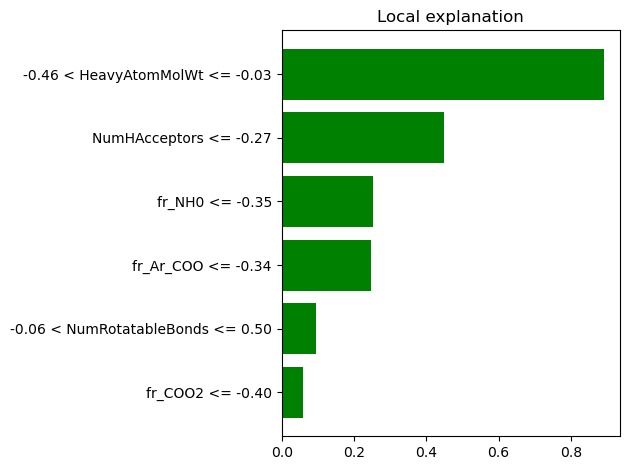

In [13]:
from sklearn.ensemble import RandomForestRegressor

from chemsar import lime_explain

rf_for_lime = RandomForestRegressor(n_estimators=50, random_state=0).fit(X_train, y_train)

# lime_explain() estimates its perturbation statistics from the full `x`
# argument passed in, not just the row(s) being explained -- so pass the
# whole test set and use `start=` to pick which row to actually explain,
# rather than a single-row DataFrame (which would give LIME nothing to
# estimate feature variance from and produce a degenerate explanation).
explanations = lime_explain(
    rf_for_lime, X_test, v_names, y_test, mode="regression", start=len(X_test) - 1
)
mol_name, observed, predicted, contributions, exp = explanations[-1]

print(f"Molecule: {mol_name}")
print(f"Observed: {observed:.2f}   Predicted: {predicted:.2f}")
for feature_desc, weight in contributions:
    print(f"  {feature_desc:35s} {weight:+.3f}")
exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

## 11. 2D structure depictions

`moltosvg()` renders a molecule to SVG -- here from `prepared_2d.sdf`, the
2D-coordinate file `mol_enumerate` already wrote in step 2. `highlight()`
does the same but highlights atoms matching a SMARTS substructure pattern,
useful for pointing out *why* a molecule matched a filter.

aspirin


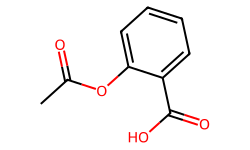

caffeine


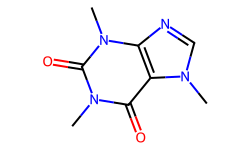

ibuprofen


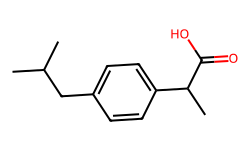

salicylic_acid


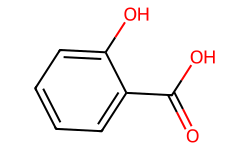

In [14]:
from IPython.display import SVG, display
from rdkit import Chem

from chemsar import highlight, moltosvg

with Chem.SDMolSupplier("prepared_2d.sdf") as suppl:
    mols_2d = {m.GetProp("_Name"): m for m in suppl if m is not None}

for name in ["aspirin", "caffeine", "ibuprofen", "salicylic_acid"]:
    print(name)
    display(SVG(moltosvg(mols_2d[name], molSize=(250, 150))))

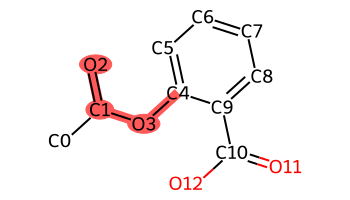

In [15]:
# Highlight the carboxylic acid / ester substructure in aspirin
display(SVG(highlight(molecules["aspirin"], "C(=O)O", size=(350, 200))))

## 12. Classification, confusion matrices, and a Keras deep-learning model

`ModelC()` mirrors `Model()` for classification, and automatically plots
train/cross-validation/test confusion matrices as a side effect of each
call. To demonstrate that without a wall of repeated plots, the comparison
loop below closes each model's figures immediately (`plt.close("all")`);
the dedicated Keras run after it leaves its figures showing.

In [16]:
# Reuse the same features, but with the synthetic activity thresholded into
# active/inactive at the median.
y_train_binary = (y_train > np.median(y_train)).astype(int)
y_test_binary = (y_test > np.median(y_test)).astype(int)

from chemsar import ModelC

classifier_candidates = ["rf", "lr", "svm"]
class_rows = []
for m_name in classifier_candidates:
    res, fitted = ModelC(
        X_train, y_train_binary, X_test, y_test_binary, v_names, M=m_name, c1=3, rs=0, cv="loo"
    )
    class_rows.append(
        {
            "model": m_name,
            "train_accuracy": res["accuracy_score_train"],
            "test_accuracy": res["accuracy_score_test"],
        }
    )
    plt.close("all")  # suppress this loop's confusion-matrix plots; see the dl run below

pd.DataFrame(class_rows).set_index("model")

,train_accuracy,test_accuracy
model,,
rf,0.857143,0.750
lr,0.714286,0.500
svm,0.952381,0.875


Now a small Keras MLP (`M="dl"`), letting its confusion matrices render:
train set, leave-one-out-style stratified cross-validation, and the
held-out test set.

2026-08-06 15:06:26.540596: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Train accuracy: 0.810
Test accuracy:  0.500


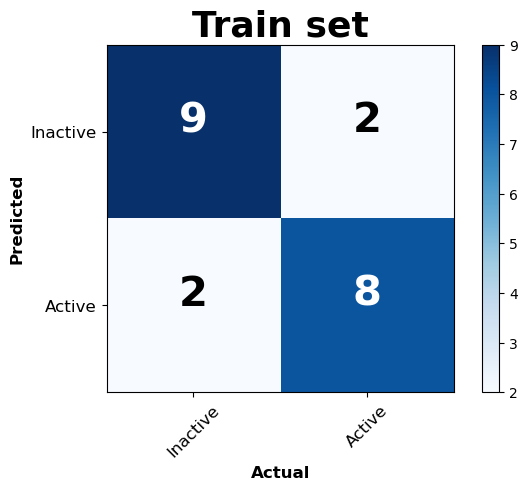

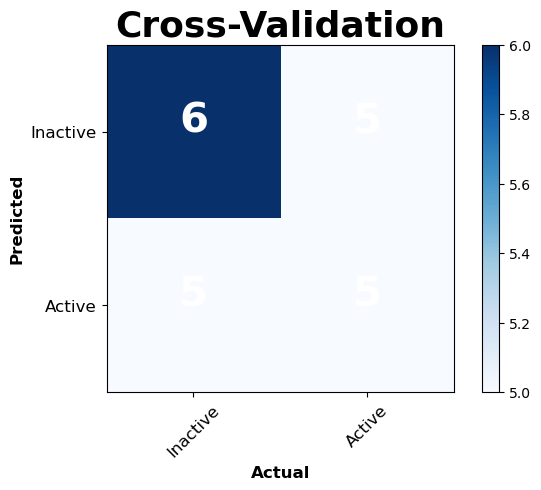

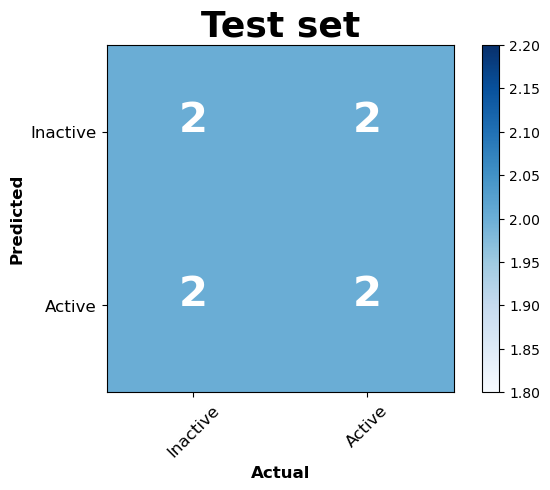

In [17]:
dl_result, dl_model = ModelC(
    X_train, y_train_binary, X_test, y_test_binary, v_names,
    M="dl", rs=0, ep=30, dl2=[8, 4], bs=8,
)
print(f"Train accuracy: {dl_result['accuracy_score_train']:.3f}")
print(f"Test accuracy:  {dl_result['accuracy_score_test']:.3f}")

## Next steps

- Swap in a real SDF/SMILES file and real activity data.
- For classification tasks with more model types, see `ModelC`'s full list
  in the repo's `README.md`.
- `chemsar.plots.plot_features()` and `chemsar.model.clus_uns()` cover
  scatter/histogram/ROC grids and PCA/K-means clustering, not shown here.
- See the module table in the repo's `README.md` for everything else
  available (fingerprints, correlation filtering, applicability-domain
  checks, ...).